In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [209]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [210]:
datasets = {
    "fund_master": fund_master,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "perf": perf,
    "txn": txn,
    "portfolio": portfolio,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.shape)


fund_master
(40, 15)

nav
(46000, 3)

aum
(90, 5)

sip
(48, 6)

category
(144, 3)

folio
(21, 6)

perf
(40, 19)

txn
(32778, 13)

portfolio
(322, 8)

benchmark
(8050, 3)


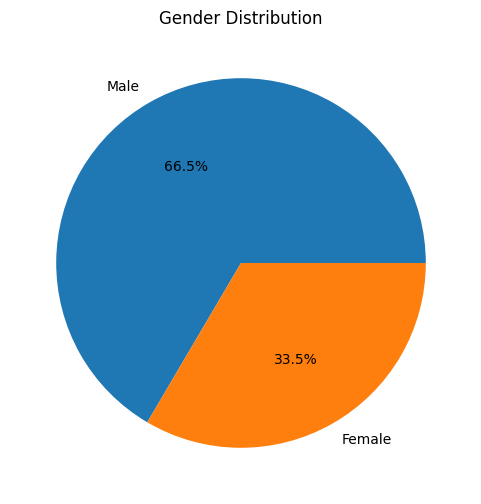

In [211]:
gender_counts = txn['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

In [212]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [213]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [214]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [215]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


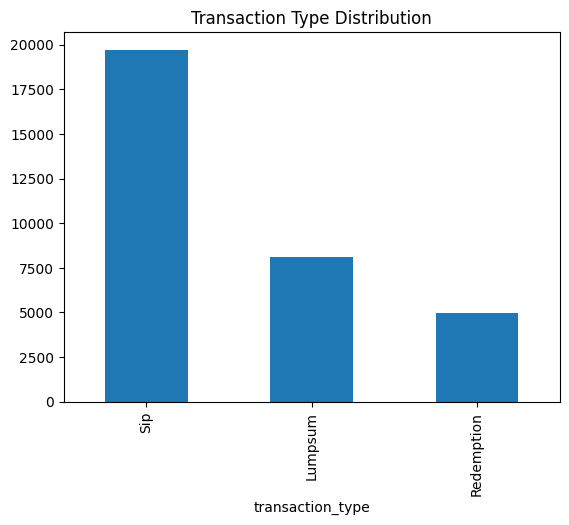

In [216]:
txn['transaction_type'].value_counts().plot(kind='bar')
plt.title("Transaction Type Distribution")
plt.show()

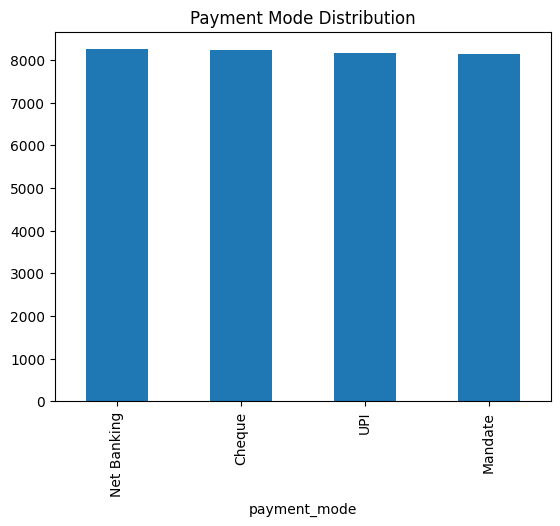

In [217]:
txn['payment_mode'].value_counts().plot(kind='bar')
plt.title("Payment Mode Distribution")
plt.show()

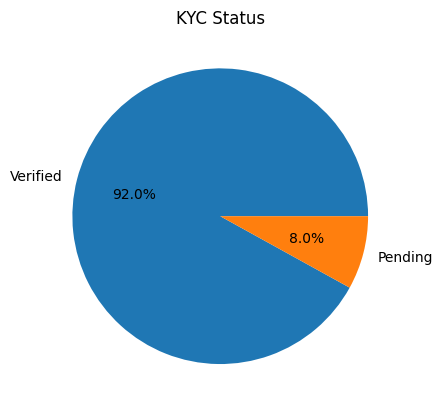

In [218]:
txn['kyc_status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("KYC Status")
plt.show()

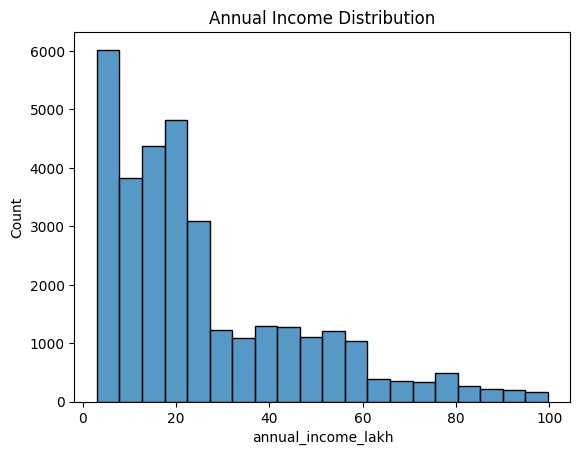

In [219]:
sns.histplot(txn['annual_income_lakh'], bins=20)
plt.title("Annual Income Distribution")
plt.show()

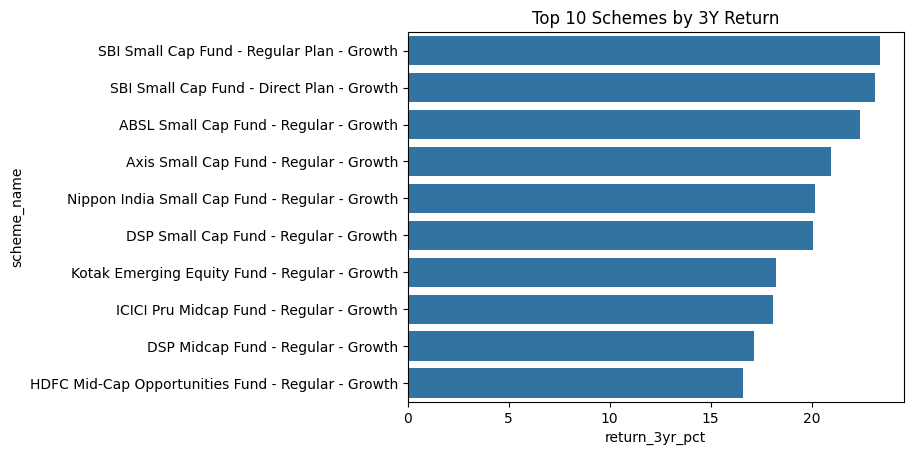

In [220]:
top = perf.sort_values('return_3yr_pct', ascending=False).head(10)

sns.barplot(data=top, x='return_3yr_pct', y='scheme_name')
plt.title("Top 10 Schemes by 3Y Return")
plt.show()

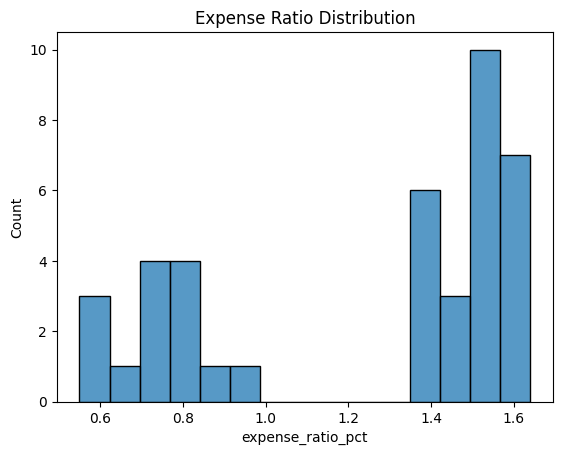

In [221]:
sns.histplot(perf['expense_ratio_pct'], bins=15)
plt.title("Expense Ratio Distribution")
plt.show()

In [222]:
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [223]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [224]:
print("AUM:", aum.columns.tolist())
print("SIP:", sip.columns.tolist())
print("PORTFOLIO:", portfolio.columns.tolist())
print("FUND:", fund_master.columns.tolist())
print("FOLIO:", folio.columns.tolist())

AUM: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
SIP: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
PORTFOLIO: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
FUND: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
FOLIO: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


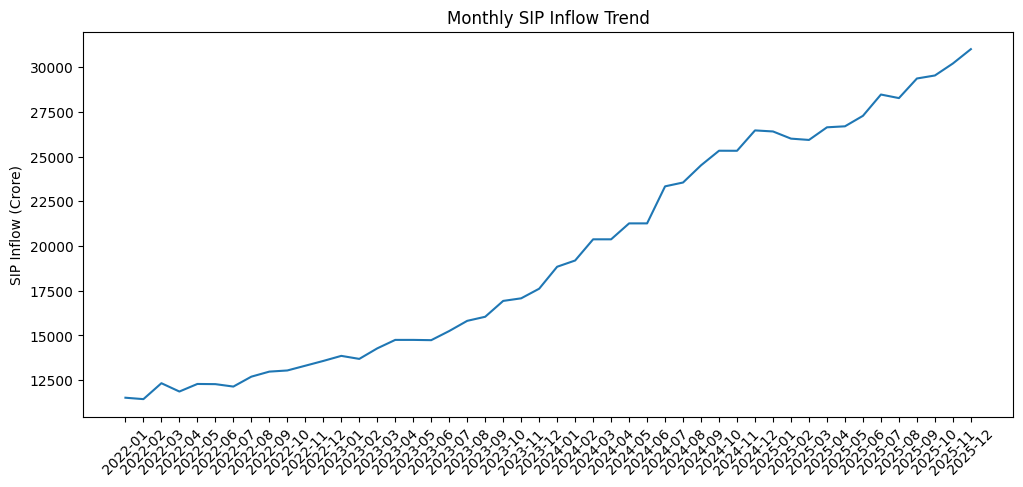

In [225]:
plt.figure(figsize=(12,5))
plt.plot(sip['month'], sip['sip_inflow_crore'])
plt.title("Monthly SIP Inflow Trend")
plt.xticks(rotation=45)
plt.ylabel("SIP Inflow (Crore)")
plt.show()

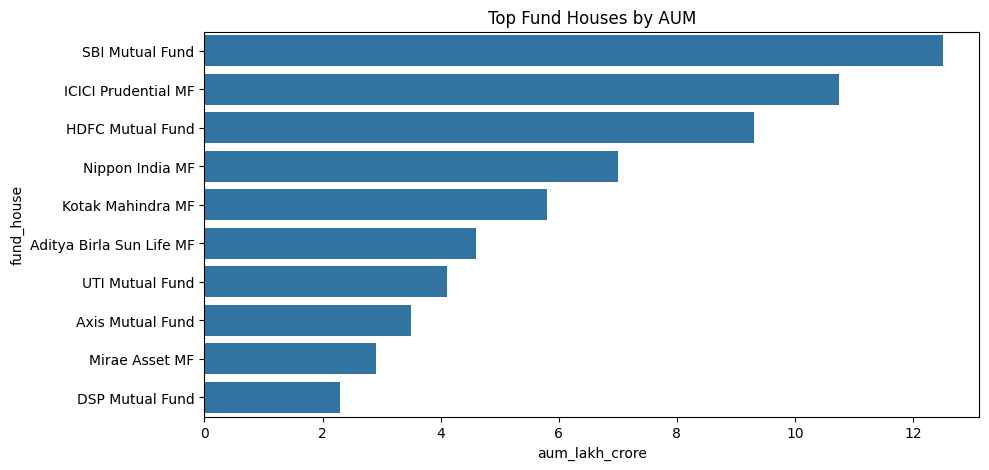

In [226]:
latest_aum = aum.sort_values('date').groupby('fund_house').tail(1)

top_aum = latest_aum.sort_values(
    'aum_lakh_crore',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_aum,
    x='aum_lakh_crore',
    y='fund_house'
)

plt.title("Top Fund Houses by AUM")
plt.show()

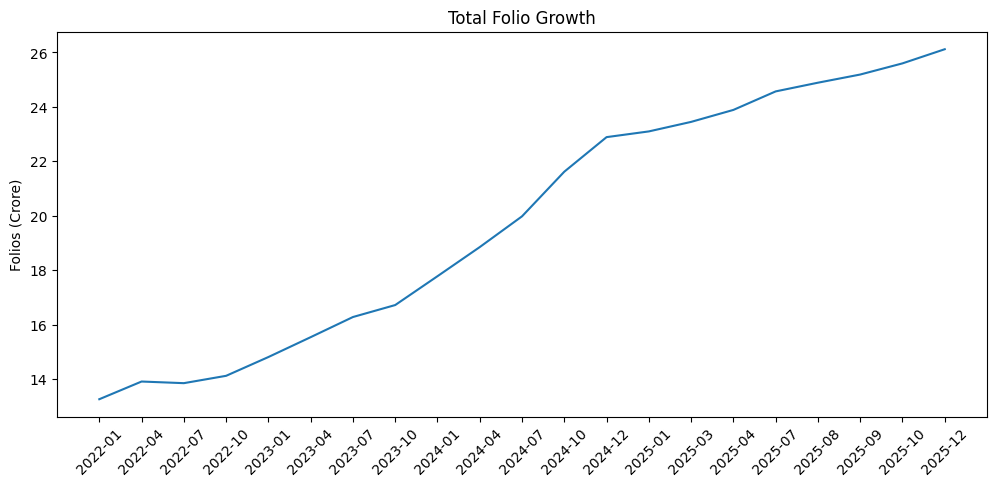

In [227]:
plt.figure(figsize=(12,5))

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.title("Total Folio Growth")
plt.xticks(rotation=45)
plt.ylabel("Folios (Crore)")
plt.show()

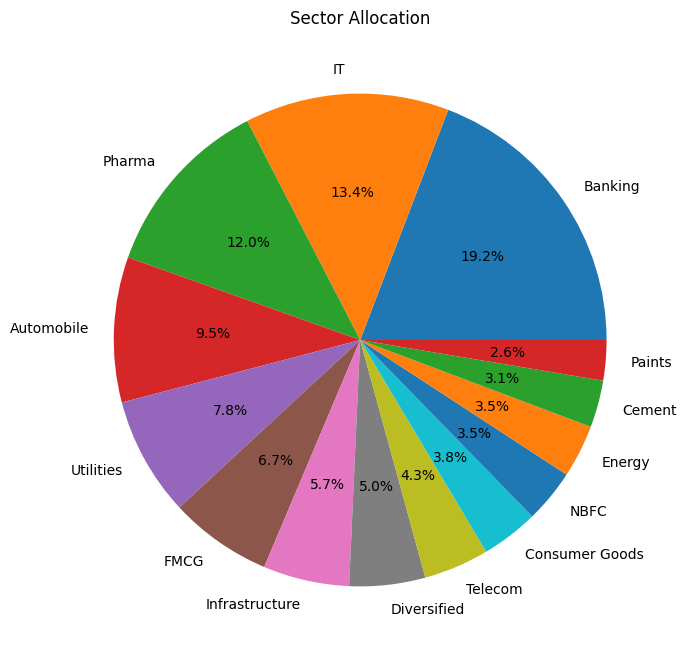

In [228]:
sector_alloc = portfolio.groupby(
    'sector'
)['weight_pct'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct='%1.1f%%'
)

plt.title("Sector Allocation")
plt.show()

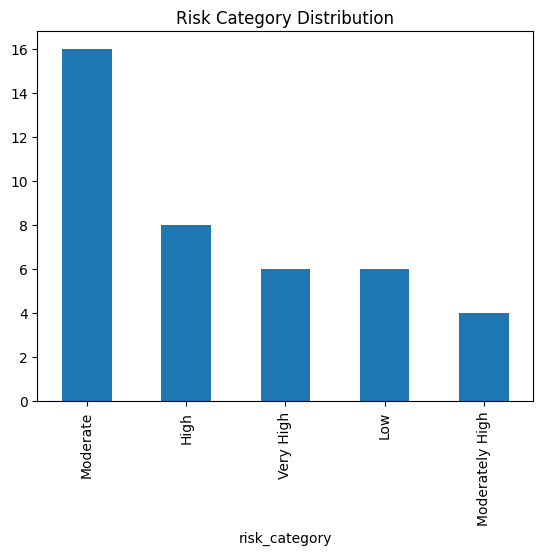

In [229]:
fund_master['risk_category'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Category Distribution")
plt.show()

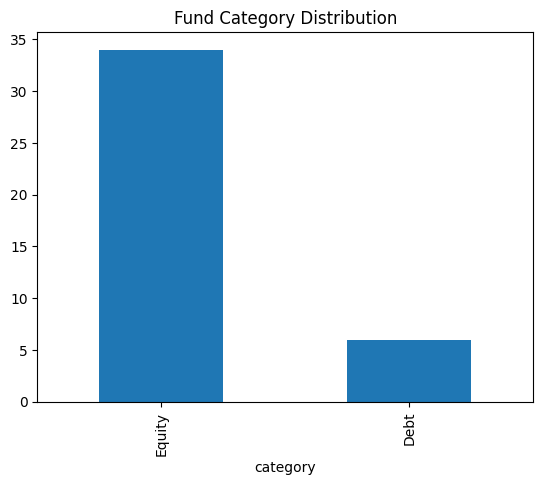

In [230]:
fund_master['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fund Category Distribution")
plt.show()

1. SIP inflows show a long-term upward trend.
2. Mutual fund folio counts have grown steadily.
3. AUM is concentrated among leading fund houses.
4. Investor participation spans multiple age groups.
5. State-wise investment activity is unevenly distributed.
6. Most investors have completed KYC verification.
7. Equity-oriented schemes dominate the dataset.
8. Fund performance varies significantly across schemes.
9. Sector allocation demonstrates portfolio diversification.
10. Risk categories are distributed across multiple investment styles.

In [231]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [232]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


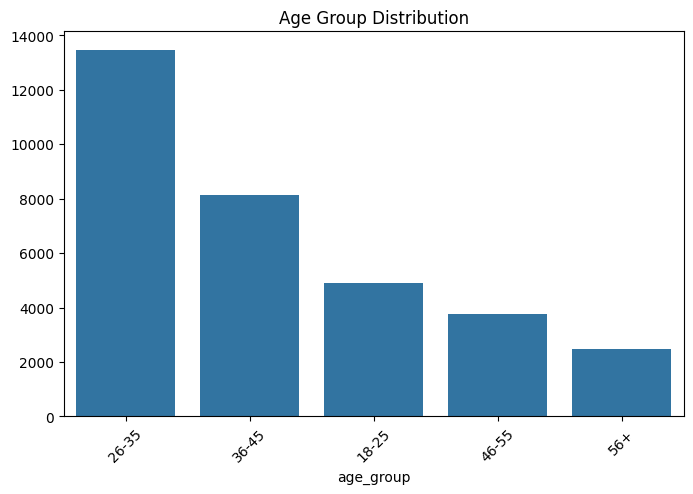

In [233]:
age_counts = txn['age_group'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.show()

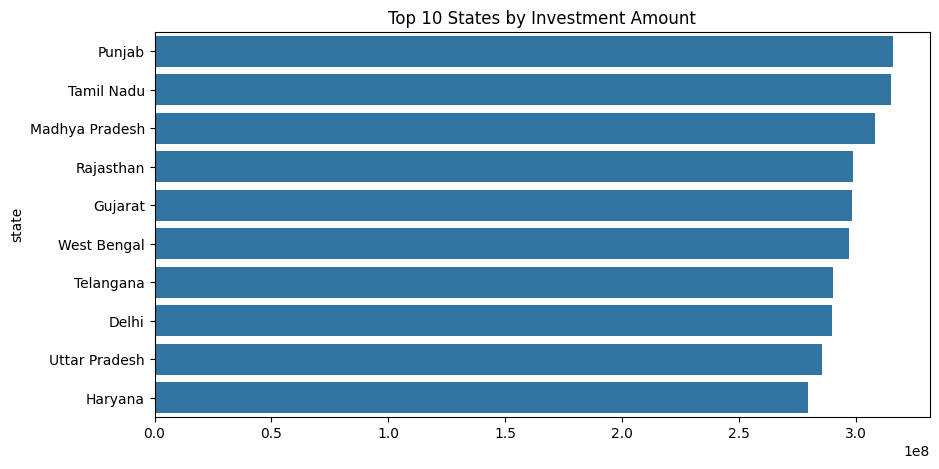

In [234]:
state_amount = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_amount.values, y=state_amount.index)
plt.title("Top 10 States by Investment Amount")
plt.show()

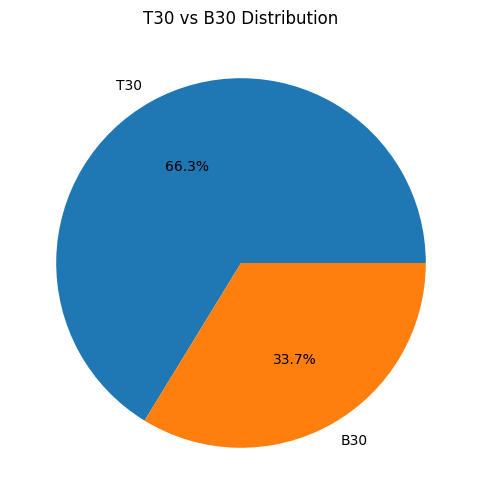

In [235]:
tier_counts = txn['city_tier'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
plt.title("T30 vs B30 Distribution")
plt.show()

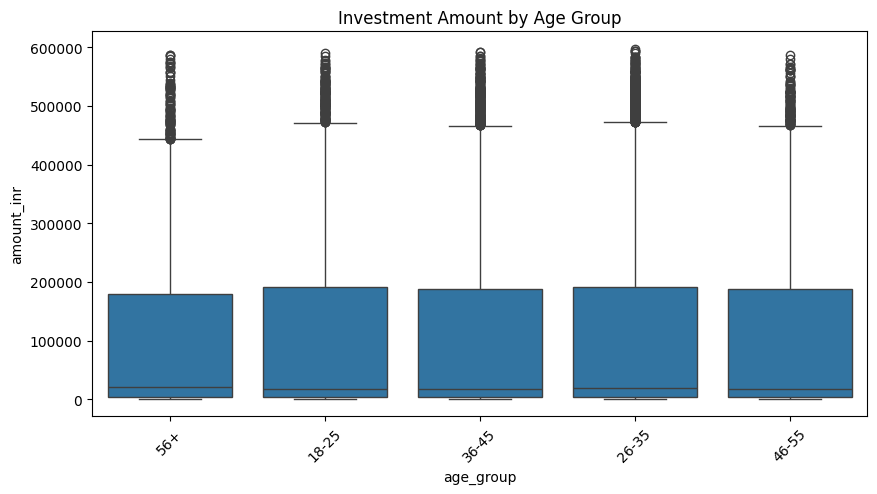

In [236]:
plt.figure(figsize=(10,5))
sns.boxplot(data=txn, x='age_group', y='amount_inr')
plt.title("Investment Amount by Age Group")
plt.xticks(rotation=45)
plt.show()

In [237]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [238]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


1. Male and female participation shows a diversified investor base.
2. Investment activity varies significantly across age groups.
3. Top states contribute a major share of total investment flows.
4. City tier distribution highlights penetration beyond major metros.
5. Investment amounts differ across investor demographics.
6. AUM is concentrated among leading fund houses.
7. SIP inflows demonstrate long-term participation trends.
8. Folio counts indicate growing mutual fund adoption.
9. Scheme performance varies across categories.
10. Sector allocation reflects portfolio diversification.

In [239]:
print(txn.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [240]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [241]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [243]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [244]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = nav.groupby(
    'amfi_code'
)['nav'].pct_change()

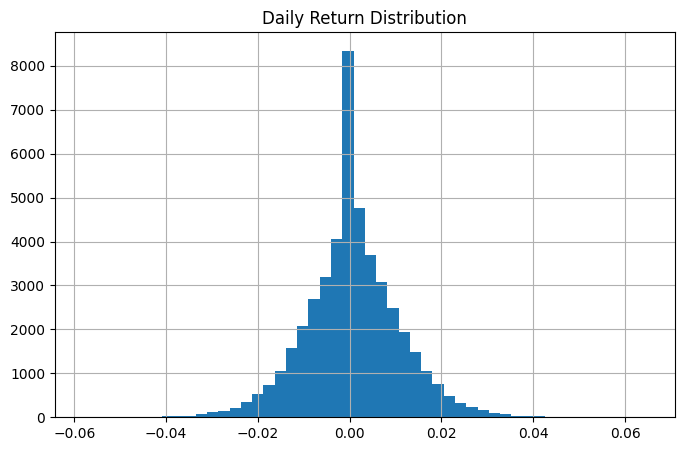

In [245]:
plt.figure(figsize=(8,5))

nav['daily_return'].dropna().hist(
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

In [246]:
cagr_results = []

for code, df in nav.groupby(
    'amfi_code'
):

    start_nav = df['nav'].iloc[0]
    end_nav = df['nav'].iloc[-1]

    years = (
        (
            df['date'].max()
            -
            df['date'].min()
        ).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
    ) - 1

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [247]:
rf = 0.065

sharpe_results = []

for code, df in nav.groupby(
    'amfi_code'
):

    returns = df[
        'daily_return'
    ].dropna()

    if len(returns) > 20:

        sharpe = (
            (
                returns.mean()*252
                -
                rf
            )
            /
            returns.std()
        ) * np.sqrt(252)

        sharpe_results.append(
            [code,sharpe]
        )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

In [248]:
sortino_results = []

for code, df in nav.groupby(
    'amfi_code'
):

    returns = df[
        'daily_return'
    ].dropna()

    downside = returns[
        returns < 0
    ]

    if len(downside) > 10:

        sortino = (
            (
                returns.mean()*252
                -
                rf
            )
            /
            downside.std()
        ) * np.sqrt(252)

        sortino_results.append(
            [code,sortino]
        )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [249]:
dd_results = []

for code, df in nav.groupby(
    'amfi_code'
):

    running_max = (
        df['nav']
        .cummax()
    )

    drawdown = (
        df['nav']
        /
        running_max
    ) - 1

    dd_results.append(
        [
            code,
            drawdown.min()
        ]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

In [250]:
benchmark = benchmark.sort_values(
    ['index_name','date']
)

benchmark['benchmark_return'] = (
    benchmark
    .groupby('index_name')
    ['close_value']
    .pct_change()
)

In [251]:
nifty100 = benchmark[
    benchmark['index_name']
    ==
    'Nifty 100'
][
    ['date',
     'benchmark_return']
]

In [252]:
cagr_df.to_csv(
    "cagr_results.csv",
    index=False
)

sharpe_df.to_csv(
    "sharpe_results.csv",
    index=False
)

sortino_df.to_csv(
    "sortino_results.csv",
    index=False
)

dd_df.to_csv(
    "max_drawdown.csv",
    index=False
)

In [253]:
print(benchmark['index_name'].unique())

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [254]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
][['date','benchmark_return']]

alpha_beta_results = []

for code, df in nav.groupby('amfi_code'):

    fund = df[['date','daily_return']].dropna()

    merged = pd.merge(
        fund,
        nifty100,
        on='date',
        how='inner'
    )

    if len(merged) > 30:

        slope, intercept, r, p, stderr = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta_results.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [255]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [256]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
    .merge(dd_df,on='amfi_code')
)

scorecard['cagr_rank'] = scorecard['cagr'].rank(
    ascending=False
)

scorecard['sharpe_rank'] = scorecard[
    'sharpe_ratio'
].rank(
    ascending=False
)

scorecard['alpha_rank'] = scorecard[
    'alpha'
].rank(
    ascending=False
)

scorecard['dd_rank'] = scorecard[
    'max_drawdown'
].rank(
    ascending=False
)

scorecard['fund_score'] = (
    scorecard['cagr_rank']*0.30
    +
    scorecard['sharpe_rank']*0.25
    +
    scorecard['alpha_rank']*0.20
    +
    scorecard['dd_rank']*0.10
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
0,100016,0.026352,-50.782301,0.037476,-0.058268,-0.247344,37.0,35.0,39.0,34.0,31.05
1,100025,0.044551,-142.907888,0.042818,0.001158,-0.043083,36.0,39.0,38.0,4.0,28.55
2,100033,0.300997,275.612083,0.271954,0.005104,-0.162172,7.0,7.0,6.0,20.0,7.05
3,101206,0.235205,258.857759,0.213998,0.021086,-0.112916,12.0,9.0,12.0,9.0,9.15
4,101207,0.079331,40.990514,0.108971,-0.065289,-0.354469,27.0,28.0,27.0,38.0,24.30


In [257]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [258]:
top5 = scorecard.sort_values(
    'fund_score'
).head(5)

top_codes = top5[
    'amfi_code'
].tolist()

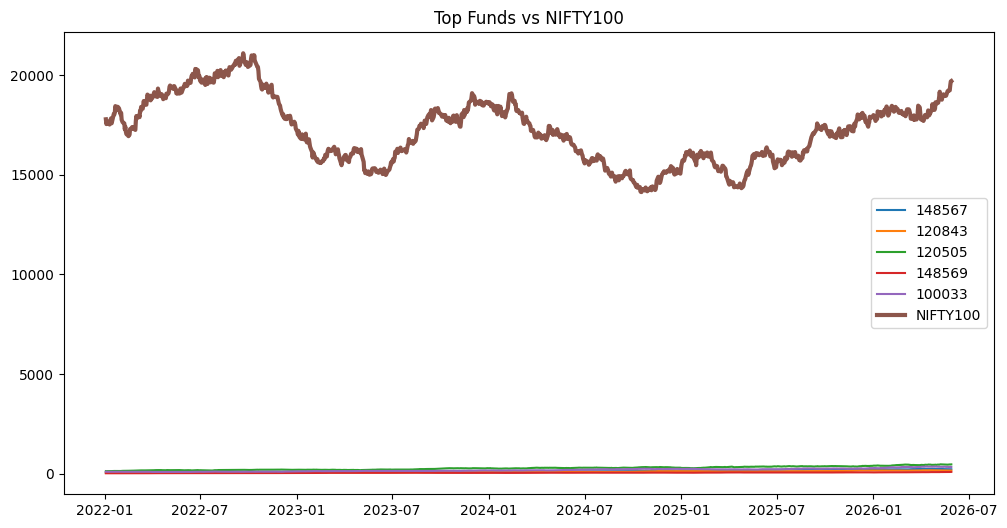

In [259]:
plt.figure(figsize=(12,6))

for code in top_codes:

    df = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        df['date'],
        df['nav'],
        label=str(code)
    )

nifty = benchmark[
    benchmark['index_name']
    ==
    'NIFTY100'
]

plt.plot(
    nifty['date'],
    nifty['close_value'],
    linewidth=3,
    label='NIFTY100'
)

plt.legend()

plt.title(
    "Top Funds vs NIFTY100"
)

plt.show()

In [260]:
plt.savefig(
    "benchmark_comparison.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>